In [1]:
using Plots
using Serialization
using SparseArrays
using Statistics

#indices_list = open("fire1.bin", "r") do file
#    deserialize(file);
#end;

In [2]:
run_path = 100
dt = 0.05
bin_msec = 5.0
# bin_delta = Float(bin_msec/dt)  # 5msec感覚

5.0

In [3]:
function histgram(filepath, run_path)
    indices_list = open(filepath, "r") do file
        deserialize(file);
    end

    # データを events 配列に変換 (時系列, ID, 試行回数)
    events = [(idx.I[1], idx.I[2], idx.I[3]) for idx in indices_list]
    
    # 最大の時系列Tを取得
    T = maximum(first.(events))+1
    
    # スパース行列で (time, id) のカウントを計算
    counts = spzeros(T, 100)  # 100 ID に対応
    for (t, id, trial) in events
        counts[t, id] += 1
    end
    
    # 100試行回数ごとの集計
    bin_size = 50  # 片側50
    output = zeros(Float32, Int(T/100))
    
    for i in 1:length(output)
        j = (i-1)*100 + 1
        lower = max(j - bin_size, 1)
        upper = min(j + bin_size, T)
        output[i] = sum(counts[lower:upper, :]) / 100  # IDと試行回数で平均化
    end
    
    return output
end

histgram (generic function with 1 method)

In [4]:
function mean_extract(inputs, target_ind, baseline_ind, time_bin)
    output = zeros(Float32, length(inputs))
   
    interb = baseline_ind[2]-baseline_ind[1]
    # 5で割る理由がなさそう(なぜやったのか...汗)
    #baseline = sum(inputs[baseline_ind[1]:baseline_ind[2]])./interb./5
    baseline = sum(inputs[baseline_ind[1]:baseline_ind[2]])./interb
    # println(baseline)
    x_t = inputs[target_ind[1]:target_ind[2]] .- baseline
    for i in 1:(Int(target_ind[2])-Int(target_ind[1]))
        # j = (i-1)*time_bin+1
        # bin = Int(ceil(time_bin/2))
        j=i
        bin = 1
        if j>bin
            # output[i] = sum(x_t[(j-bin):(j+bin)])/3
            output[i] = sum(x_t[(j-bin):(j+bin)])
        else
            # output[i] = sum(x_t[j:(j+bin)])/3
            output[i] = sum(x_t[j:(j+bin)])
        end
    end
    return findmax(output)[1]
end

mean_extract (generic function with 1 method)

In [5]:
function std_extract(inputs, target_ind, baseline_ind, time_bin)
    output = zeros(Float32, length(inputs))
   
    interb = baseline_ind[2]-baseline_ind[1]
    # 5で割る理由がなさそう(なぜやったのか...汗)
    #baseline = sum(inputs[baseline_ind[1]:baseline_ind[2]])./interb./5
    baseline = sum(inputs[baseline_ind[1]:baseline_ind[2]])./interb
    # println(baseline)
    x_t = inputs[target_ind[1]:target_ind[2]] .- baseline
    for i in 1:(Int(target_ind[2])-Int(target_ind[1]))
        # j = (i-1)*time_bin+1
        # bin = Int(ceil(time_bin/2))
        j=i
        bin = 1
        if j>bin
            # output[i] = sum(x_t[(j-bin):(j+bin)])/3
            output[i] = sum(x_t[(j-bin):(j+bin)])
        else
            # output[i] = sum(x_t[j:(j+bin)])/3
            output[i] = sum(x_t[j:(j+bin)])
        end
    end
    return std(output)
end

std_extract (generic function with 1 method)

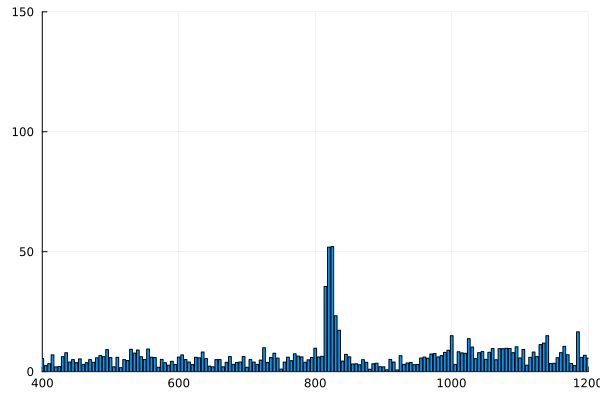

In [73]:
# x 軸を5倍に変換
output = histgram("../outputs/tonic_width_010/fire5.bin", run_path)
x_vals = (1:length(output)) .* 5  # 各 x 値を5倍にする

# プロット
plot(x_vals, output, st=:bar, legend=false, xlim=(80*5, 240*5), ylim=(0,150))

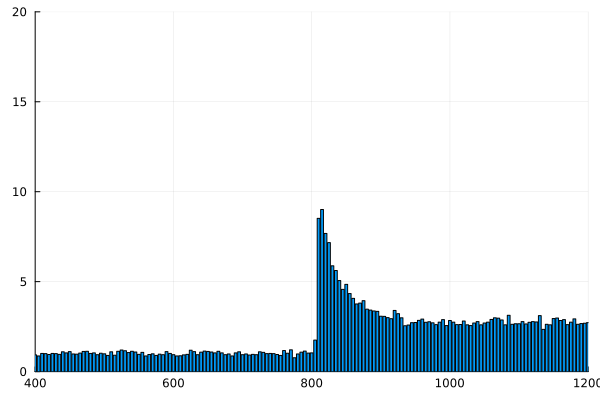

In [71]:
# x 軸を5倍に変換
output = histgram("../outputs/tonic_width_010/fire1.bin", run_path)
x_vals = (1:length(output)) .* 5  # 各 x 値を5倍にする

# プロット
plot(x_vals, output, st=:bar, legend=false, xlim=(80*5, 240*5), ylim=(0,20))

## ラスタープロット

pipelines/main.jlで実行した結果を呼び出して、ラスタープロットを作成する。

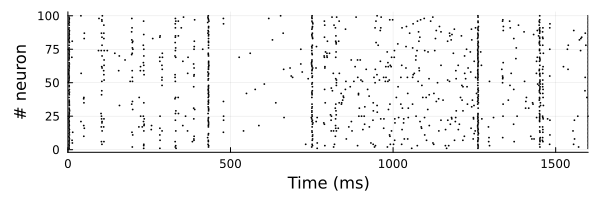

In [26]:
using Distributions, Random

@kwdef mutable struct SimulationParams
    Ne::Int = 80
    Ni::Int = 20
    NiC::Int = 30
    NeC::Int = 1
    NiE::Int = 100
    T::Float64 = 1600.0
    dt::Float64 = 0.05
    V_exc::Float64 = 0.0
    Er::Float64 = -70.0
    V_inh::Float64 = -65.0
    threshold::Float64 = 40.0
    nt::Int = 0
    d::Any = Normal(1.0, 0.5)
end

function SimulationParams(; Ne, Ni, NiC, NeC, NiE, T, dt, V_exc, Er, V_inh, threshold, d)
    nt = Int(T / dt)  # nt を T/dt で計算
    return SimulationParams(Ne, Ni, NiC, NeC, NiE, T, dt, V_exc, Er, V_inh, threshold, nt, d)
end

params = SimulationParams(
    Ne=100,
    Ni=0,
    NeC=1,
    NiC=30,
    NiE=100,
    T=1600.0,
    dt=0.05,
    V_exc=.0,
    Er=-65.0,
    V_inh=-70.0,
    threshold=-40.0,
    d=Normal(1.0, 0.5)
)

indices_list = open("../outputs/fire1.bin", "r") do file
    deserialize(file);
end

# 例えば試行回数がn番目の試行に対応するインデックスを抽出する
target_trial = 1
filtered_indices = filter(x -> x[3] == target_trial, indices_list)

resolution = 1/params.dt

# 抽出したインデックスからラスタープロットのデータを準備
spike_times = [x[1] for x in filtered_indices]./resolution  # 時間軸のデータ
neuron_ids = [x[2] for x in filtered_indices]       # 試行番号

# ラスタープロットを作成
scatter(
    spike_times, neuron_ids, xlabel="Time (ms)", ylabel="# neuron", legend=false,
    markersize=1, color="black", size=(600,200), xlim=(0,1600),
    left_margin = 5Plots.mm, bottom_margin = 5Plots.mm
)

In [9]:
using Glob

C_interval = [700,900]./5
C_interval = convert(Array{Int,1}, C_interval)
A_interval = [900,1100]./5
A_interval = convert(Array{Int,1}, A_interval)

function extact_output(filepaths)
    result = []
    result_std = []
    
    for filepath in filepaths
        println(filepath)
        try
            # エラーが発生する可能性のある処理
            output = histgram(filepath, run_path)
            append!(result, mean_extract(output, C_interval, A_interval, 5))
            append!(result_std, std_extract(output, C_interval, A_interval, 5))
        catch e
            if isa(e, ArgumentError)
                println("ファイルに発火イベントがありません: ", e)
            else
                println("その他のエラー: ", e)
            end
        end
    end
    return result, result_std
end

tonic_mean, tonic_std = extact_output(glob("../outputs/tonic_width_*/fire5.bin"))
phasic_mean, phasic_std = extact_output(glob("../outputs/phasic_width_*/fire5.bin"))

../outputs/tonic_width_010/fire5.bin
../outputs/tonic_width_030/fire5.bin
../outputs/tonic_width_050/fire5.bin
../outputs/tonic_width_100/fire5.bin
../outputs/tonic_width_150/fire5.bin
../outputs/tonic_width_300/fire5.bin
../outputs/phasic_width_010/fire5.bin
../outputs/phasic_width_030/fire5.bin
../outputs/phasic_width_050/fire5.bin
../outputs/phasic_width_100/fire5.bin
../outputs/phasic_width_150/fire5.bin
../outputs/phasic_width_300/fire5.bin


(Any[114.615f0, 105.14075f0, 83.17575f0, 49.67675f0, 38.1535f0, 29.751f0], Any[10.889394f0, 10.893857f0, 9.980748f0, 7.219567f0, 5.528473f0, 4.8837566f0])

In [10]:
labels = [10,30,50,100,150,200]

p = plot(labels, tonic_mean, color="blue", label="Tonic", yerr=tonic_std, marker=:circle)
p = plot!(labels, phasic_mean, color="red", label="Phasic", yerr=phasic_std, marker=:rect)
plot(p,
    xlabel = "Width (msec)", 
    ylabel= "Xp (spikes)", 
    xtickfont=font(14), 
    ytickfont=font(14), guidefont=font(14),
    legendfont=font(14), legend=true)
savefig("Width_change_2024_0226.pdf")

"/Users/yukihiro-su/Desktop/Programing/Julia/SakuLab/Repository/src/Width_change_2024_0226.pdf"

In [63]:
using Glob

C_interval = [700,900]./5
C_interval = convert(Array{Int,1}, C_interval)
A_interval = [900,1100]./5
A_interval = convert(Array{Int,1}, A_interval)

function extact_output(filepaths)
    result = []
    result_std = []
    
    for filepath in filepaths
        println(filepath)
        try
            # エラーが発生する可能性のある処理
            output = histgram(filepath, run_path)
            append!(result, mean_extract(output, C_interval, A_interval, 5))
            append!(result_std, std_extract(output, C_interval, A_interval, 5))
        catch e
            if isa(e, ArgumentError)
                println("ファイルに発火イベントがありません: ", e)
            else
                println("その他のエラー: ", e)
            end
        end
    end
    return result, result_std
end

tonic_mean, tonic_std = extact_output(glob("../outputs/tonic_fdiff_*/fire2.bin"))
#phasic_mean, phasic_std = extact_output(glob("../outputs/phasic_fdiff_*/fire2.bin"))

../outputs/tonic_fdiff_100/fire2.bin
../outputs/tonic_fdiff_200/fire2.bin
../outputs/tonic_fdiff_300/fire2.bin
../outputs/tonic_fdiff_400/fire2.bin
../outputs/tonic_fdiff_500/fire2.bin
../outputs/tonic_fdiff_600/fire2.bin


(Any[25.987503f0, 55.173748f0, 87.12049f0, 109.5875f0, 127.63351f0, 138.07825f0], Any[2.4457114f0, 4.752255f0, 7.3203454f0, 9.358731f0, 10.939523f0, 12.096101f0])

In [8]:
labels = [100,200,300,400,500,600]
p = plot(labels, tonic_mean, color="blue", label="Tonic", yerr=tonic_std, marker=:circle)
p = plot!(labels, phasic_mean, color="red", label="Phasic", yerr=phasic_std, marker=:rect)
plot(p,
    xlabel = "Frequency change (Hz)", 
    ylabel= "Xp (spikes)", 
    xtickfont=font(14), 
    ytickfont=font(14), guidefont=font(14),
    legendfont=font(14), legend=true)
savefig("Fdiff_change_20240225.pdf")

"/Users/yukihiro-su/Desktop/Programing/Julia/SakuLab/Repository/src/Fdiff_change_20240225.pdf"

In [27]:
tonic_mean

8-element Vector{Any}:
 48.397747f0
 61.53575f0
 64.71849f0
 66.34f0
 78.75374f0
 92.7495f0
 83.897f0
 97.866745f0

In [28]:
phasic_mean

8-element Vector{Any}:
 25.381248f0
 52.2975f0
 64.396255f0
 63.704247f0
 64.70349f0
 84.43125f0
 83.97f0
 94.235f0